In [4]:
import pickle
import pandas as pd

import matplotlib.pyplot as plt

import numpy as np
import seaborn as sns

In [7]:
file_path = '../maizedata/zma_all_preds.pkl' # Replace with your file's actual path
with open(file_path, 'rb') as file:
    data = pickle.load(file)
    
# data=data[['gene_ID','protein_ID','family','seq', 'activity_avg']]

In [38]:
Activator=np.array([], dtype=float)
noactivity=np.array([], dtype=float)

allactivity=np.array([], dtype=float)

for i in range(len(data["gene_ID"])):
    arr = np.asarray(data.iloc[i, 4], dtype=float)

    # ignore NaNs explicitly (optional but clean)
    arr = arr[np.isfinite(arr)]
    
    

    if arr.size == 0:
        data.at[i, "Action"] = "None"
        continue
        
    allactivity=np.concatenate((allactivity,arr))

    has_pos = np.any(arr >= 3)
    # has_neg = np.any(arr < -1)
    
    has_neg = np.all(arr <= 1)

    if has_pos:
        # print(temp.iloc[i, 0], "Activator")
        data.at[i, "Action"] = "Activator"
        Activator=np.concatenate((Activator,arr))

    # elif has_neg and not has_pos:
    #     # print(temp.iloc[i, 0], "Repressor")
    #     data.at[i, "Action"] = "Repressor"

    # elif has_pos and has_neg:
    #     # print(temp.iloc[i, 0], "Both")
    #     data.at[i, "Action"] = "Dual Action"
    elif has_neg:
        data.at[i, "Action"] = "No activity"
        noactivity=np.concatenate((noactivity,arr))
        

    else:
        data.at[i, "Action"] = "None"
        # noactivity=np.concatenate((noactivity,arr))

In [1]:
# data['Action']

In [57]:
# len(set(data[data['family']=='FAR1']['gene_ID']))

In [56]:
# set(data[data['family']=='FAR1']['gene_ID']).intersection(ortholog)

In [54]:
ortholog=pd.read_csv('../results/ortholog.csv')
ortholog=set(ortholog['SorghumGene'])

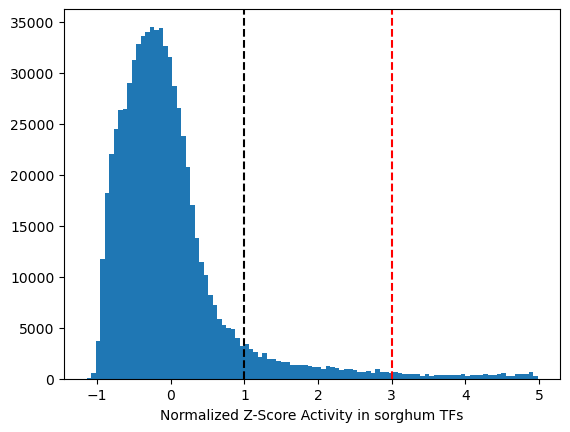

In [45]:
plt.hist(allactivity, bins=100)

plt.axvline(x=3, color='r', linestyle='--')

plt.axvline(x=1, color='black', linestyle='--')

plt.xlabel('Normalized Z-Score Activity in sorghum TFs')

plt.savefig('../results/sorghum_allactivity_distribution.png', dpi=300, bbox_inches='tight')

Text(0.5, 0, 'Normalized Z-Score Activity in inactive sorghum TFs')

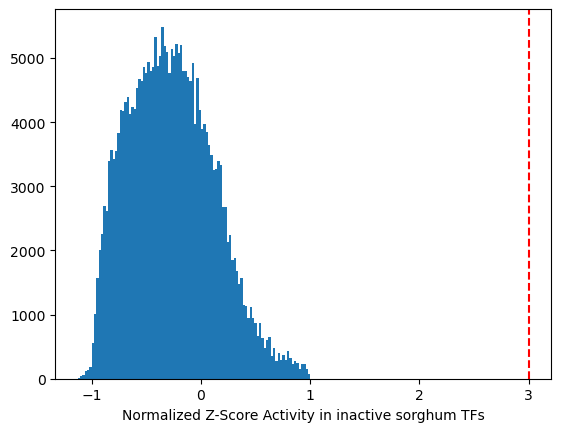

In [40]:
plt.hist(noactivity, bins=100)
# plt.axvline(x=0.5, color='r', linestyle='--')
# plt.axvline(x=-0.8, color='r', linestyle='--')


plt.xlabel('Normalized Z-Score Activity in inactive sorghum TFs')

# plt.savefig('../results/sorghum_noactivity_distribution.png', dpi=300, bbox_inches='tight')

# plt.savefig('../results/maize_noactivity_distribution.png', dpi=300, bbox_inches='tight')

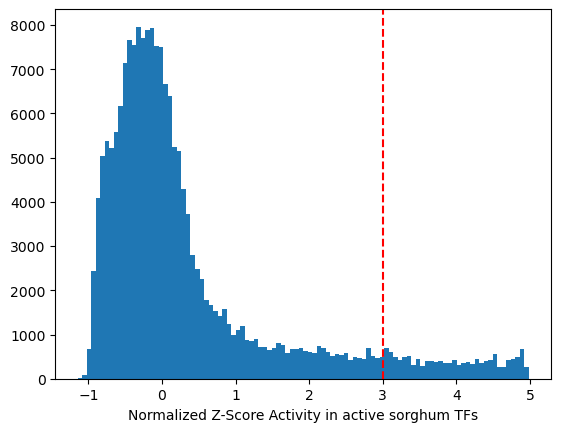

In [37]:
plt.hist(Activator, bins=100)

plt.xlabel('Normalized Z-Score Activity in active sorghum TFs')
plt.axvline(x=3, color='r', linestyle='--')

# plt.savefig('../results/sorghum_activity_distribution.png', dpi=300, bbox_inches='tight')

# plt.savefig('../results/maize_activity_distribution.png', dpi=300, bbox_inches='tight')

In [15]:
LOW  = -0.8
HIGH =  0.5

for i in range(len(data["gene_ID"])):
    arr = np.asarray(data.iloc[i, 4], dtype=float)

    # ignore NaNs explicitly (optional but clean)
    arr = arr[np.isfinite(arr)]

    if arr.size == 0:
        data.at[i, "RecategorizeAction"] = "None"
        continue

    has_pos = np.any(arr > 3)
    # has_neg = np.any(arr < -1)

    if has_pos:
        # print(temp.iloc[i, 0], "Activator")
        data.at[i, "RecategorizeAction"] = "Activator"
        Activator=np.concatenate((Activator,arr))

    # elif has_neg and not has_pos:
    #     # print(temp.iloc[i, 0], "Repressor")
    #     data.at[i, "Action"] = "Repressor"

    # elif has_pos and has_neg:
    #     # print(temp.iloc[i, 0], "Both")
    #     data.at[i, "Action"] = "Dual Action"

    if np.all((arr >= LOW) & (arr <= HIGH)):
        data.at[i, "RecategorizeAction"] = "No Activity"
        # Flat.append(arr)

In [2]:
# data['RecategorizeAction'].value_counts()

In [18]:
data.to_csv('../sorghumdata/Sorghum_ActivityAnnotated.csv', index=False)

# data.to_csv('Sorghum_ActivityAnnotated.csv', index=False)

In [3]:
# countdata=pd.read_csv('combined_gene_counts.csv')
# countdata

In [4]:
# countdata=pd.merge(countdata, data, left_on='Gene', right_on='gene_ID')
# countdata

In [5]:
# sns.histplot(
#     data=countdata,
#     x="Count",
#     hue="Action",
#     shrink=0.8,
#     bins=100,
#     stat='density'
# )

# # 
# ax=plt.gca()
# # ax.legend(title="Action")

# plt.xlabel('number of maize genes significantly affected')
# # plt.legend(title='Action')


# plt.savefig('Histogram_maizegenes_TFs.png', dpi=300)

In [6]:
# ax = sns.kdeplot(
#     data=countdata,
#     x="Count",
#     hue="Action",
#     common_norm=False,
#     fill=True,
#     alpha=0.3
# )
# plt.xlim(-10,20000)
# plt.xlabel('number of maize genes significantly affected')
# # ax.legend(title="Action")
# plt.savefig('Histogram_maizegenes_TFs_densityplot.png', dpi=300)

In [7]:
# countdata

In [9]:
# file_path = '../maizedata/zma_all_preds.pkl' # Replace with your file's actual path
# with open(file_path, 'rb') as file:
#     maizedata = pickle.load(file)
    
# maizedata=maizedata[['gene_ID','protein_ID','family','seq', 'activity_avg']]
# maizedata

In [11]:
sorghumgene='Sobic.005G022400'
maizegene='Zm00001eb093480'
arr = data.loc[data['gene_ID']==sorghumgene, 'activity_avg'].iloc[0]
arr = np.asarray(arr, dtype=float)
# arr

arr2 = maizedata.loc[maizedata['gene_ID']==maizegene, 'activity_avg'].iloc[0]
arr2 = np.asarray(arr2, dtype=float)
# arr2
# sns.lineplot(data.iloc[1800,4])
# sns.lineplot(data.iloc[1814,4])
sns.lineplot(arr, label=sorghumgene)
sns.lineplot(arr2, label=maizegene)
# plt.xlabel(f'{data.iloc[1800,0]}_{data.iloc[1814,0]}')

plt.xlabel('protein position')

plt.savefig(f'../results/{sorghumgene}_{maizegene}.png', dpi=300)

In [33]:
# arr2